In [12]:
# Regular EDA and plotting libraries
import numpy as np  #tableaux et matrices
import pandas as pd # Permet de manipuler et d'analyser des données sous forme de dataframes, ce qui est similaire à des tableaux Excel
import matplotlib.pyplot as plt  #Permet de créer des visualisations de données, comme des graphiques et des diagrammes.
import seaborn as sns #  Permet de créer des visualisations de données plus complexes et plus attrayantes que celles fournies par matplotlib.

# We want our plots to appear in notebook
# Afin de visualiser les graphiques dans le notebook
%matplotlib inline 

# Configuration pour éviter les warnings de dépréciation de pandas
pd.set_option('future.no_silent_downcasting', True)

# Importation des métriques
from sklearn.metrics import accuracy_score

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score #utilisés pour diviser les données en ensembles d'entraînement et de test, et pour évaluer les modèles à l'aide de la validation croisée.
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV #pour ajuster les hyperparamètres des modèles.
from sklearn.metrics import confusion_matrix, classification_report # pour évaluer les performances des modèles de classification.
from sklearn.metrics import precision_score, recall_score, f1_score #pour évaluer les performances des modèles de classification.
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+( utilisez une version antérieure de Scikit-Learn) #utilisé pour afficher la courbe ROC des modèles de classification.

# Print last updated
import time
print(f"Last updated: {time.asctime()}")

Last updated: Tue Apr 14 18:49:43 2026


In [13]:
df = pd.read_csv("../data/real_estate_data.csv") # 'DataFrame' shortened to 'df'  # charger le jeu de données 
df.shape # (rows, columns)  # afficher sa taille

(5653, 12)

In [14]:
# And the top 10
df.head(10) #Cela affichera les 10 premières lignes du DataFrame 

,titre,prix,prix_num,categorie,ville,localisation,type,nombre_p,time_posted,date_posted,month_posted,year_posted
0,À louer – Bureaux neufs S+1 et S+2 à Monastir ...,650 DT,650,Location Appartements,Monastir,Monastir,location,S+1,2/4/26 12:37,02-04-26,2,2026
1,S+1 haut standing pour la saison universitaire,850 DT,850,Location Appartements,Monastir,Monastir,location,S+1,8/30/25 10:49,08-30-25,8,2025
2,à vendre s+3 haut standing directement au prom...,350000 DT,350000,Vente Appartements,Monastir,Bekalta,vente,S+3,7/30/25 12:45,07-30-25,7,2025
3,Appartement s+1 vue sur mer pour vacance d’été...,1540 DT,1540,Location de vacances,Monastir,Bekalta,location,S+1,6/17/25 9:41,06-17-25,6,2025
4,Studio mignon estivale,55 DT,55,Location Appartements,Monastir,Monastir,location,S+0,6/10/25 20:59,06-10-25,6,2025
5,S+2 à louer pour longue durée,550 DT,550,Location Appartements,Monastir,Monastir,location,S+2,5/26/25 14:58,05-26-25,5,2025
6,A vendre S+1 lumineux à Folla Monastir,430000 DT,430000,Vente Appartements,Monastir,Monastir,vente,S+1,5/21/25 10:18,05-21-25,5,2025
7,À vendre Superbe S+1 à Folla Monastir,400000 DT,400000,Vente Appartements,Monastir,Monastir,vente,S+1,5/21/25 9:51,05-21-25,5,2025
8,À vendre Superbe S+1 sur mer à Folla Monastir,430000 DT,430000,Vente Appartements,Monastir,Monastir,vente,S+1,5/13/25 11:02,05-13-25,5,2025
9,À vendre – Superbe S+1 à Folla Monastir,400000 DT,400000,Vente Appartements,Monastir,Monastir,vente,S+1,5/10/25 11:23,05-10-25,5,2025


In [15]:
#changer noms des attributs

df = df.rename(columns={
    "titre": "title",
    "prix": "price_text",
    "prix_num": "price",
    "categorie": "category",
    "ville": "city",
    "localisation": "location",
    "type": "type_transaction",
    "nombre_p": "rooms",
    "time_posted": "post_time",
    "date_posted": "post_date",
    "month_posted": "post_month",
    "year_posted": "post_year"
})

In [16]:
# Encodage des variables catégorielles
df = df.replace({
    # Type de transaction
    "type_transaction": {"location": 0, "vente": 1},
    
    # Catégories
    "category": {
        "Location Appartements": 0,
        "Vente Appartements": 1,
        "Location de vacances": 2,
        "Vente Maisons": 3,
        "Location Maisons": 4
    },
    
    # Nombre de pièces (extraire le nombre)
    "rooms": {
        "S+0": 0, "S+1": 1, "S+2": 2, "S+3": 3, 
        "S+4": 4, "S+5": 5, "S+6": 6, "S+7": 7, "S+8": 8
    }
}).infer_objects(copy=False)

# Pour les villes et localisations, utilisons One-Hot Encoding plus tard
# Pour l'instant, gardons-les comme telles pour l'exploration

print("Vérification des types après encodage:")
print(df[['category', 'type_transaction', 'rooms']].dtypes)
print("\nExemple des valeurs encodées:")
print(df[['category', 'type_transaction', 'rooms']].head())

Vérification des types après encodage:
category             int64
type_transaction     int64
rooms               object
dtype: object

Exemple des valeurs encodées:
   category  type_transaction rooms
0         0                 0     1
1         0                 0     1
2         1                 1     3
3         2                 0     1
4         0                 0     0


In [17]:
df.head(10)

,title,price_text,price,category,city,location,type_transaction,rooms,post_time,post_date,post_month,post_year
0,À louer – Bureaux neufs S+1 et S+2 à Monastir ...,650 DT,650,0,Monastir,Monastir,0,1,2/4/26 12:37,02-04-26,2,2026
1,S+1 haut standing pour la saison universitaire,850 DT,850,0,Monastir,Monastir,0,1,8/30/25 10:49,08-30-25,8,2025
2,à vendre s+3 haut standing directement au prom...,350000 DT,350000,1,Monastir,Bekalta,1,3,7/30/25 12:45,07-30-25,7,2025
3,Appartement s+1 vue sur mer pour vacance d’été...,1540 DT,1540,2,Monastir,Bekalta,0,1,6/17/25 9:41,06-17-25,6,2025
4,Studio mignon estivale,55 DT,55,0,Monastir,Monastir,0,0,6/10/25 20:59,06-10-25,6,2025
5,S+2 à louer pour longue durée,550 DT,550,0,Monastir,Monastir,0,2,5/26/25 14:58,05-26-25,5,2025
6,A vendre S+1 lumineux à Folla Monastir,430000 DT,430000,1,Monastir,Monastir,1,1,5/21/25 10:18,05-21-25,5,2025
7,À vendre Superbe S+1 à Folla Monastir,400000 DT,400000,1,Monastir,Monastir,1,1,5/21/25 9:51,05-21-25,5,2025
8,À vendre Superbe S+1 sur mer à Folla Monastir,430000 DT,430000,1,Monastir,Monastir,1,1,5/13/25 11:02,05-13-25,5,2025
9,À vendre – Superbe S+1 à Folla Monastir,400000 DT,400000,1,Monastir,Monastir,1,1,5/10/25 11:23,05-10-25,5,2025


In [18]:
df.dtypes  # Donne le type de données de chaque colonne

title               object
price_text          object
price                int64
category             int64
city                object
location            object
type_transaction     int64
rooms               object
post_time           object
post_date           object
post_month           int64
post_year            int64
dtype: object

In [19]:
#Afficher la somme des valeurs manquantes

print("Nombre de valeur manquantes:",df.isnull().sum().sum())

Nombre de valeur manquantes: 0


In [20]:
# Vérifier les doublons
duplicate_rows = df[df.duplicated()]
print("Nombre de lignes dupliquées:", duplicate_rows.shape[0])

Nombre de lignes dupliquées: 21


In [21]:
# Vérification des outliers
print("\nVérification des outliers :")
for column in ['price', 'post_month', 'post_year']:  # Colonnes numériques principales
    if column in df.columns and df[column].dtype in ['int64', 'float64']:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)].index
        print(f"{column}: {len(outliers)} outliers")


Vérification des outliers :
price: 303 outliers
post_month: 0 outliers
post_year: 1051 outliers


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Initialiser le scaler
scaler = MinMaxScaler()

# Sélectionner uniquement les colonnes numériques déjà encodées
numeric_columns = ['price', 'post_month', 'post_year']
# Ajouter les colonnes catégorielles encodées si elles sont bien numériques
if df['category'].dtype in ['int64', 'float64']:
    numeric_columns.append('category')
if df['type_transaction'].dtype in ['int64', 'float64']:
    numeric_columns.append('type_transaction')
if df['rooms'].dtype in ['int64', 'float64']:
    numeric_columns.append('rooms')

print(f"Colonnes numériques pour normalisation: {numeric_columns}")

# Normaliser les colonnes numériques
df_normalized = df.copy()
df_normalized[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("Dataset normalisé avec Min-Max Scaling:")
print(df_normalized[numeric_columns].head())

Colonnes numériques pour normalisation: ['price', 'post_month', 'post_year', 'category', 'type_transaction']
Dataset normalisé avec Min-Max Scaling:
          price  post_month  post_year  category  type_transaction
0  3.095238e-06    0.090909        1.0      0.00               0.0
1  4.047619e-06    0.636364        0.0      0.00               0.0
2  1.666667e-03    0.545455        0.0      0.25               1.0
3  7.333333e-06    0.454545        0.0      0.50               0.0
4  2.619048e-07    0.454545        0.0      0.00               0.0


In [23]:
#Afficher la somme des valeurs manquantes
df.isnull().sum()

title               0
price_text          0
price               0
category            0
city                0
location            0
type_transaction    0
rooms               0
post_time           0
post_date           0
post_month          0
post_year           0
dtype: int64

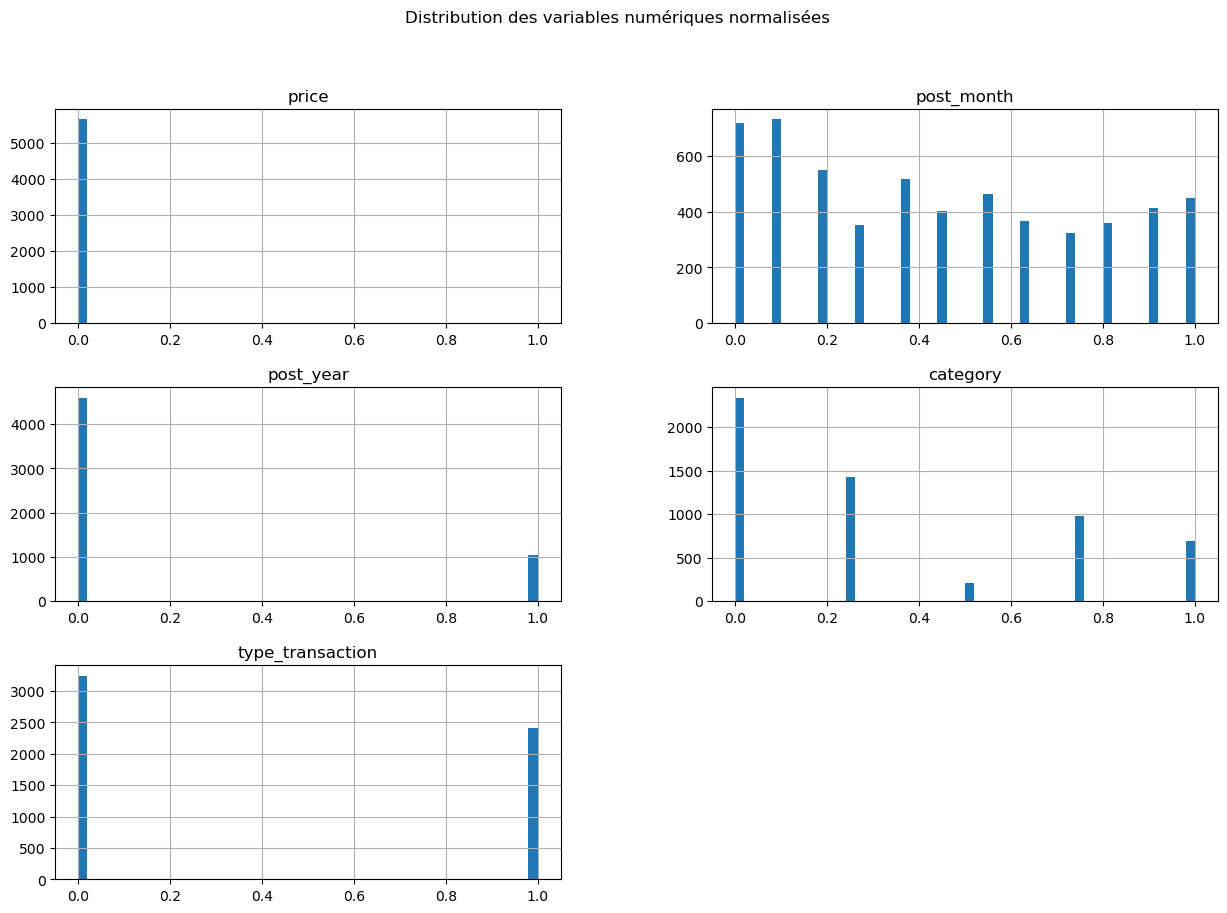

In [24]:
# Afficher l'histogramme des colonnes numériques normalisées
df_normalized[numeric_columns].hist(bins=50, figsize=(15, 10))
plt.suptitle('Distribution des variables numériques normalisées')
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

# Initialiser le scaler
scaler = StandardScaler()

# Standardiser les colonnes numériques
df_standardized = df.copy()
df_standardized[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("Dataset standardisé avec Z-score Scaling:")
print(df_standardized[numeric_columns].head())

Dataset standardisé avec Z-score Scaling:
      price  post_month  post_year  category  type_transaction
0 -0.066760   -1.059467   2.092531 -0.915153         -0.860809
1 -0.066709    0.605115  -0.477890 -0.915153         -0.860809
2  0.023071    0.327685  -0.477890 -0.231027          1.161698
3 -0.066531    0.050254  -0.477890  0.453099         -0.860809
4 -0.066913    0.050254  -0.477890 -0.915153         -0.860809


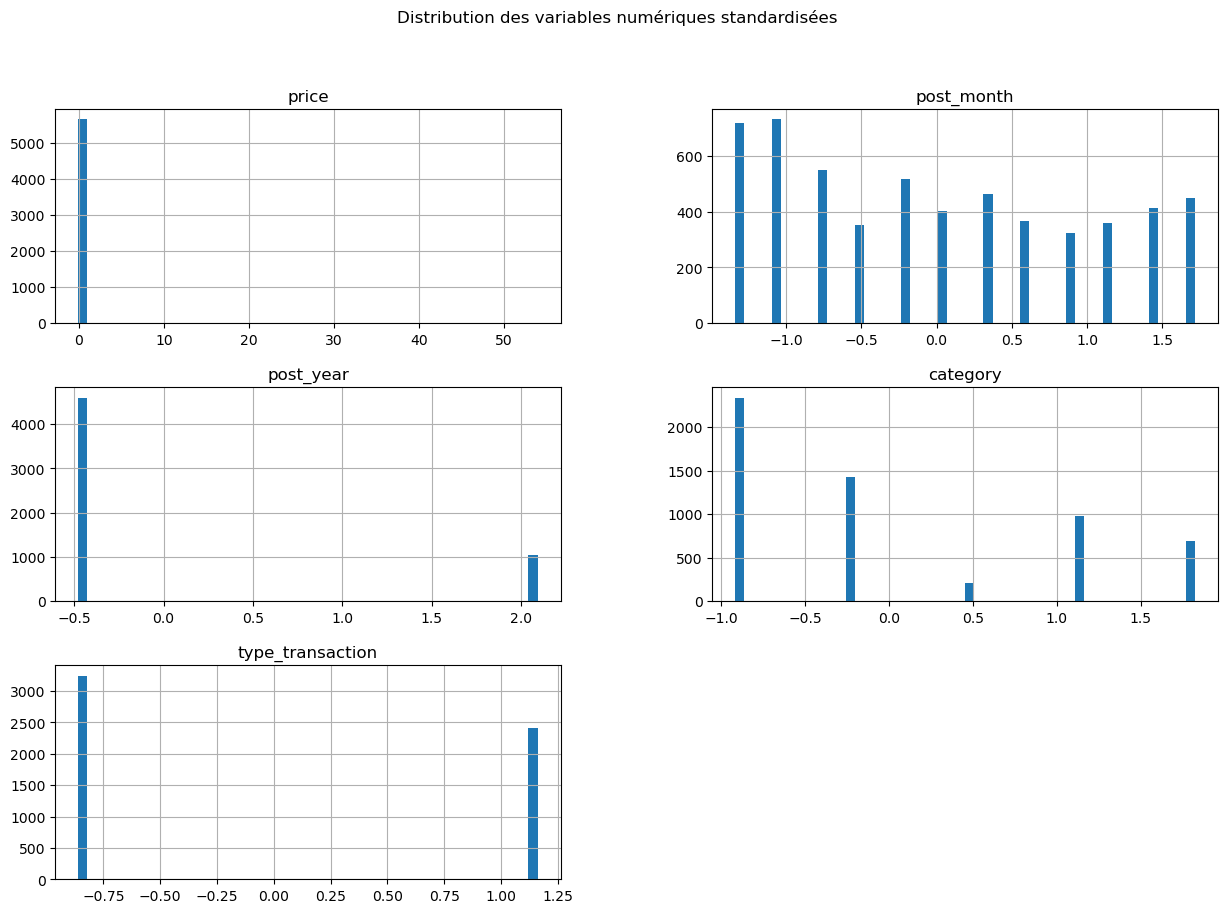

In [26]:
# Afficher l'histogramme des colonnes standardisées
df_standardized[numeric_columns].hist(bins=50, figsize=(15, 10))
plt.suptitle('Distribution des variables numériques standardisées')
plt.show()

In [27]:
# One-Hot Encoding pour les variables catégorielles nominales
categorical_columns = ['city', 'location']
df_encoded = pd.get_dummies(df, columns=categorical_columns, prefix=['city', 'loc'])

print("Dataset avec One-Hot Encoding:")
print(f"Nouvelles dimensions: {df_encoded.shape}")
print("\nNouvelles colonnes créées:")
new_columns = [col for col in df_encoded.columns if col.startswith('city_') or col.startswith('loc_')]
print(f"Colonnes encodées: {len(new_columns)}")
print(f"Exemples de nouvelles colonnes: {new_columns[:5]}")
print("\nAperçu des données encodées:")
print(df_encoded[['price', 'category', 'type_transaction', 'rooms'] + new_columns[:3]].head())

Dataset avec One-Hot Encoding:
Nouvelles dimensions: (5653, 107)

Nouvelles colonnes créées:
Colonnes encodées: 97
Exemples de nouvelles colonnes: ['city_Ariana', 'city_Ben arous', 'city_Bizerte', 'city_Kairouan', 'city_Mahdia']

Aperçu des données encodées:
    price  category  type_transaction rooms  city_Ariana  city_Ben arous  \
0     650         0                 0     1        False           False   
1     850         0                 0     1        False           False   
2  350000         1                 1     3        False           False   
3    1540         2                 0     1        False           False   
4      55         0                 0     0        False           False   

   city_Bizerte  
0         False  
1         False  
2         False  
3         False  
4         False  


In [28]:
# Enregistrer le DataFrame modifié dans un nouveau fichier CSV
df.to_csv("../data/real_estate_processed.csv", index=False)
print("Dataset traité enregistré sous: ../data/real_estate_processed.csv")

Dataset traité enregistré sous: ../data/real_estate_processed.csv
